In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pdfplumber
import re

## Extração de temas do Quadro Comparativo do PLP 68/2024

In [128]:
pdf_path = "../data/quadros_emendas/PLP_68_2024/DOC-Quadro-Comparativo---SF249584956519-20241210.pdf"

# Definimos onde as divisões verticais devem ficar (eixo X)
# Ajustei os valores baseados no seu log do PyMuPDF
# [Início, Divisão 1, Divisão 2, Divisão 3, Fim]
colunas_x = [65, 245, 425, 705, 780]

table_settings = {
    "vertical_strategy": "explicit",
    "explicit_vertical_lines": colunas_x,
    "horizontal_strategy": "text",  # Como não tem linhas horizontais, usamos o alinhamento do texto
    "intersection_tolerance": 15,    # Tolerância para textos levemente desalinhados
}

all_data = []

print("Iniciando extração...")

with pdfplumber.open(pdf_path) as pdf:
    for i, page in enumerate(pdf.pages):
        # Extrai a tabela usando as coordenadas manuais
        table = page.extract_table(table_settings)
        
        if table:
            for row in table:
                print(row)
                # Limpeza básica de cada célula
                clean_row = [str(cell).replace('\n', ' ').strip() if cell else "" for cell in row]
                
                # Regra de ouro: Só aceitamos a linha se a primeira célula 
                # (Emenda) começar com um número ou for o cabeçalho
                if clean_row[0] and (clean_row[0].isdigit() or "Emenda" in clean_row[0]):
                    all_data.append(clean_row)
        
        if i % 50 == 0:
            print(f"Páginas processadas: {i}")
        break



Iniciando extração...
['', '', '', 'SF/2423']
['', '', '', '']
['Emenda Autor', 'TEMA', 'Objeto', 'Análise']
['', '', '', '']
['1 Senador Esperidião Amin', 'Transição - Compensação Benefícios', 'Propõe estabelecer que o recolhimento a fundo estadual ou', 'REJEITADA']
['(PP/SC)', 'ICMS', 'distrital configura condição onerosa para fruição de incentivo ou', '']
['', '', 'benefício fiscal.', '']
['', '', '', '']
['2 Senador Esperidião Amin', 'Regime Específico - Combustíveis', 'Propõe alterar a redação ao § 6° do art. 169, estabelecendo que, a', 'ACATADA']
['(PP/SC)', '', 'partir de 2029, a alíquota do IBS será fixada de modo a não', '']
['', '', 'exceder a carga tributária calculada conforme o § 5º, reajustada', '']
['', '', 'pela variação do preço médio ponderado de venda ao consumidor', '']
['', '', 'final, considerando os 12 meses anteriores a julho do ano anterior', '']
['', '', 'ao da fixação da alíquota.', '']
['', '', '', '']
['3 Senador Esperidião Amin', 'Regime Diferenciado CBS -

In [150]:
import pdfplumber
import pandas as pd
import re

pdf_path = "../data/quadros_emendas/PLP_68_2024/DOC-Quadro-Comparativo---SF249584956519-20241210.pdf"

# Suas divisórias coordenadas (ajustadas conforme o log anterior)
colunas_x = [65, 245, 425, 705, 780] 

table_settings = {
    "vertical_strategy": "explicit",
    "explicit_vertical_lines": colunas_x,
    "horizontal_strategy": "text",
    "intersection_tolerance": 15,
}

all_emendas = []
emenda_atual = None

print("Iniciando extração com acumulação de linhas...")

with pdfplumber.open(pdf_path) as pdf:
    for i, page in enumerate(pdf.pages):
        table = page.extract_table(table_settings)
        
        if table:
            for row in table:
                # 1. Limpeza básica
                clean_row = [str(cell).strip() if cell else "" for cell in row]
                
                # Ignora linhas totalmente vazias ou ruídos de rodapé/cabeçalho
                if not any(clean_row) or "SF/" in clean_row[3] or "Emenda Autor" in clean_row[0]:
                    continue

                # 2. Identifica se a linha é o INÍCIO de uma nova emenda
                # Checamos se a primeira coluna começa com um número (ex: "1 Senador...")
                match_inicio = re.match(r'^(\d+)\s+(.*)', clean_row[0])
                
                if match_inicio:
                    # Se já vínhamos processando uma emenda, salva ela antes de começar a nova
                    if emenda_atual:
                        all_emendas.append(emenda_atual)
                    
                    numero_emenda = match_inicio.group(1)
                    autor_inicial = match_inicio.group(2)
                    
                    # Cria o dicionário da nova emenda
                    emenda_atual = {
                        "num_emenda": int(numero_emenda),
                        "autor": autor_inicial,
                        "tema": clean_row[1],
                        "objeto": clean_row[2],
                        "análise": clean_row[3]
                    }
                else:
                    # 3. Se NÃO começa com número, é continuação da emenda anterior
                    if emenda_atual:
                        if clean_row[0]: emenda_atual["autor"] += " " + clean_row[0]
                        if clean_row[1]: emenda_atual["tema"] += " " + clean_row[1]
                        if clean_row[2]: emenda_atual["objeto"] += " " + clean_row[2]
                        if clean_row[3]: emenda_atual["análise"] += " " + clean_row[3]

    # Não esqueça de salvar a última emenda processada após o loop
    if emenda_atual:
        all_emendas.append(emenda_atual)

# Criar o DataFrame
df_plp_68 = pd.DataFrame(all_emendas)

# Limpeza final: remove espaços duplos criados pela junção de linhas
for col in ["autor", "tema", "objeto", "análise"]:
    df_plp_68[col] = df_plp_68[col].str.replace(r'\s+', ' ', regex=True).str.strip()

print(f"Sucesso! {len(df_plp_68)} emendas completas extraídas.")

# Visualizar as primeiras linhas
print(df_plp_68.head())

# Salvar
#df.to_excel("quadro_comparativo_final.xlsx", index=False)

Iniciando extração com acumulação de linhas...
Sucesso! 1976 emendas completas extraídas.
   num_emenda                                      autor  \
0           1            Senador Esperidião Amin (PP/SC)   
1           2            Senador Esperidião Amin (PP/SC)   
2           3            Senador Esperidião Amin (PP/SC)   
3           4  Senador Mecias de Jesus (REPUBLICANOS/RR)   
4           5  Senador Mecias de Jesus (REPUBLICANOS/RR)   

                                          tema  \
0      Transição - Compensação Benefícios ICMS   
1             Regime Específico - Combustíveis   
2  Regime Diferenciado CBS - Regime Automotivo   
3                      Áreas de Livre Comércio   
4                      Áreas de Livre Comércio   

                                              objeto    análise  
0  Propõe estabelecer que o recolhimento a fundo ...  REJEITADA  
1  Propõe alterar a redação ao § 6° do art. 169, ...    ACATADA  
2  Propõe nova redação aos incisos do caput do ar.

In [151]:
set(range(1, 1997)) - set(df_plp_68["num_emenda"].apply(lambda x: int(x)).values.tolist())

{44,
 166,
 168,
 169,
 215,
 224,
 256,
 263,
 837,
 838,
 839,
 842,
 1243,
 1253,
 1264,
 1265,
 1275,
 1318,
 1619,
 1672,
 1746}

In [152]:
df_plp_68

,num_emenda,autor,tema,objeto,análise
0,1,Senador Esperidião Amin (PP/SC),Transição - Compensação Benefícios ICMS,Propõe estabelecer que o recolhimento a fundo ...,REJEITADA
1,2,Senador Esperidião Amin (PP/SC),Regime Específico - Combustíveis,"Propõe alterar a redação ao § 6° do art. 169, ...",ACATADA
2,3,Senador Esperidião Amin (PP/SC),Regime Diferenciado CBS - Regime Automotivo,Propõe nova redação aos incisos do caput do ar...,REJEITADA
3,4,Senador Mecias de Jesus (REPUBLICANOS/RR),Áreas de Livre Comércio,Propõe incluir a suspensão da incidência do IB...,ACATADA
4,5,Senador Mecias de Jesus (REPUBLICANOS/RR),Áreas de Livre Comércio,Propõe incluir créditos presumidos de IBS e CB...,REJEITADA
...,...,...,...,...,...
1971,1993,Senador Nelsinho Trad (PSD/MS),Simples Nacional,Acrescenta o § 12-B ao art. 26 da Lei Compleme...,REJEITADA
1972,1994,Senador Rogério Carvalho (PT/SE),Imposto Seletivo (Incidência),Propõe adequar o texto do art. 411 à lógica tr...,ACATADA
1973,1995,Senador Humberto Costa (PT/PE),Diferimento - produtores rurais,Estabelece diferimento do IBS e CBS para insum...,ACATADA
1974,1996,Senador Flávio Bolsonaro (PL/RJ),Imposto Seletivo (Incidência),Inclui artigos para estruturar o Imposto Selet...,ACATADA


### Processamento dos temas

In [153]:
plp_68_hiearquia = pd.read_csv("../data/temas/PLP_68_hierarquia.csv")

In [154]:
plp_68_hiearquia

,tema_macro,tema_nivel_2,tema
0,Avaliação Quinquenal,Avaliação Quinquenal,Avaliação Quinquenal
1,Avaliação Quinquenal,Avaliação Quinquenal,Avaliação Quinquenal - Audiências públicas
2,Avaliação Quinquenal,Avaliação Quinquenal,Avaliação Quinquenal - CBNA
3,Avaliação Quinquenal,Avaliação Quinquenal,Avaliação Quinquenal - Contratos vigentes
4,Avaliação Quinquenal,Avaliação Quinquenal,Avaliação Quinquenal - comparativos internacio...
...,...,...,...
256,ZPE,ZPE,ZPE
257,Zona Franca de Manaus,Zona Franca de Manaus,Zona Franca de Manaus
258,Zona Franca de Manaus,Zona Franca de Manaus,Zona Franca de Manaus - Suspensão
259,Zona Franca de Manaus,Zona Franca de Manaus,Zona Franca de Manaus e ALC


In [155]:
df_plp_68.loc[
    df_plp_68["tema"] == "Matéria Estranha - ICMS Combustíveis",
    "tema"
] = "Matéria estranha - ICMS Combustíveis"

In [156]:
df_plp_68_com_temas = df_plp_68.merge(
    plp_68_hiearquia,
    on="tema",
    how="left"
)

In [157]:
df_plp_68_com_temas.head()

,num_emenda,autor,tema,objeto,análise,tema_macro,tema_nivel_2
0,1,Senador Esperidião Amin (PP/SC),Transição - Compensação Benefícios ICMS,Propõe estabelecer que o recolhimento a fundo ...,REJEITADA,Transição,Transição
1,2,Senador Esperidião Amin (PP/SC),Regime Específico - Combustíveis,"Propõe alterar a redação ao § 6° do art. 169, ...",ACATADA,Regime Específico,Regime Específico - Combustíveis
2,3,Senador Esperidião Amin (PP/SC),Regime Diferenciado CBS - Regime Automotivo,Propõe nova redação aos incisos do caput do ar...,REJEITADA,Regime Diferenciado,Regime Diferenciado
3,4,Senador Mecias de Jesus (REPUBLICANOS/RR),Áreas de Livre Comércio,Propõe incluir a suspensão da incidência do IB...,ACATADA,Áreas de Livre Comércio,Áreas de Livre Comércio
4,5,Senador Mecias de Jesus (REPUBLICANOS/RR),Áreas de Livre Comércio,Propõe incluir créditos presumidos de IBS e CB...,REJEITADA,Áreas de Livre Comércio,Áreas de Livre Comércio


In [158]:
# Configuração estética para o artigo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

def plot_tema_dist(df, col="tema", top_n=50):
    # 1. Cálculo das frequências
    counts = df[col].value_counts().reset_index()
    counts.columns = [col, "Frequência"]
    
    # 2. Filtragem para garantir legibilidade (Top N)
    # Com 200+ temas, focar nos mais representativos é melhor para o paper
    plot_df = counts.head(top_n)
    
    # 3. Criação do gráfico
    plt.figure(figsize=(12, 10))
    
    ax = sns.barplot(
        data=plot_df,
        x="Frequência",
        y=col,
        hue=col,
        palette="viridis",
        legend=False
    )
    
    # 4. Ajustes finos
    plt.title(f"Top {top_n} Temas mais Frequentes - PLP 68/2024", fontsize=15, pad=20)
    plt.xlabel("Quantidade de Emendas", fontsize=12)
    plt.ylabel("Tema", fontsize=12)
    
    # Adiciona os números nas barras para facilitar a leitura rápida
    for i in ax.containers:
        ax.bar_label(i, padding=5)

    plt.tight_layout()
    plt.show()

In [159]:
df_plp_68_com_temas[df_plp_68_com_temas["tema"] == ""]

,num_emenda,autor,tema,objeto,análise,tema_macro,tema_nivel_2
1861,1883,Senador Efraim Filho (UNIÃO/PB),,Introduz a possibilidade de transferir crédito...,REJEITADA,NaN,NaN
1883,1905,Senadora Augusta Brito (PT/CE),,Institui o uso compulsório da Nota Fiscal de S...,REJEITADA,NaN,NaN


In [160]:
df_plp_68_com_temas = df_plp_68_com_temas[df_plp_68_com_temas["tema"] != ""].reset_index(drop=True)

In [161]:
sorted(df_plp_68_com_temas["tema"].unique().tolist())

['Avaliação Quinquenal',
 'Avaliação Quinquenal - Audiências públicas',
 'Avaliação Quinquenal - CBNA',
 'Avaliação Quinquenal - Contratos vigentes',
 'Avaliação Quinquenal - comparativos internacionais',
 'Bens de Capital',
 'Bens de Capital - Ausência ato conjunto',
 'Bens de Capital - Concessionárias',
 'Bens de Capital - Construção Civil',
 'Bens de Capital - Locação',
 'Bens de Capital - Produtor Rural',
 'Bens de Capital - Reidi',
 'Bens de Capital - Reporto',
 'Bens de Capital - Retid',
 'Bens de Capital - Simples Nacional',
 'CBNA',
 'CBNA - alimentos coloniais',
 'CBNA - arroz em casca',
 'CBNA - arroz todos os tipos',
 'CBNA - bacalhau',
 'CBNA - bebidas lácteas',
 'CBNA - bolachas e biscoitos',
 'CBNA - castanhas',
 'CBNA - cães e gatos',
 'CBNA - erva mate',
 'CBNA - farinhas, açaí, tapioca, doces caseiros',
 'CBNA - incluir produtos',
 'CBNA - leite cru',
 'CBNA - mel',
 'CBNA - pessoas com erros inatos metabolismo',
 'CBNA - sucos',
 'CBNA - óleos vegetais',
 'CBNA - óleo

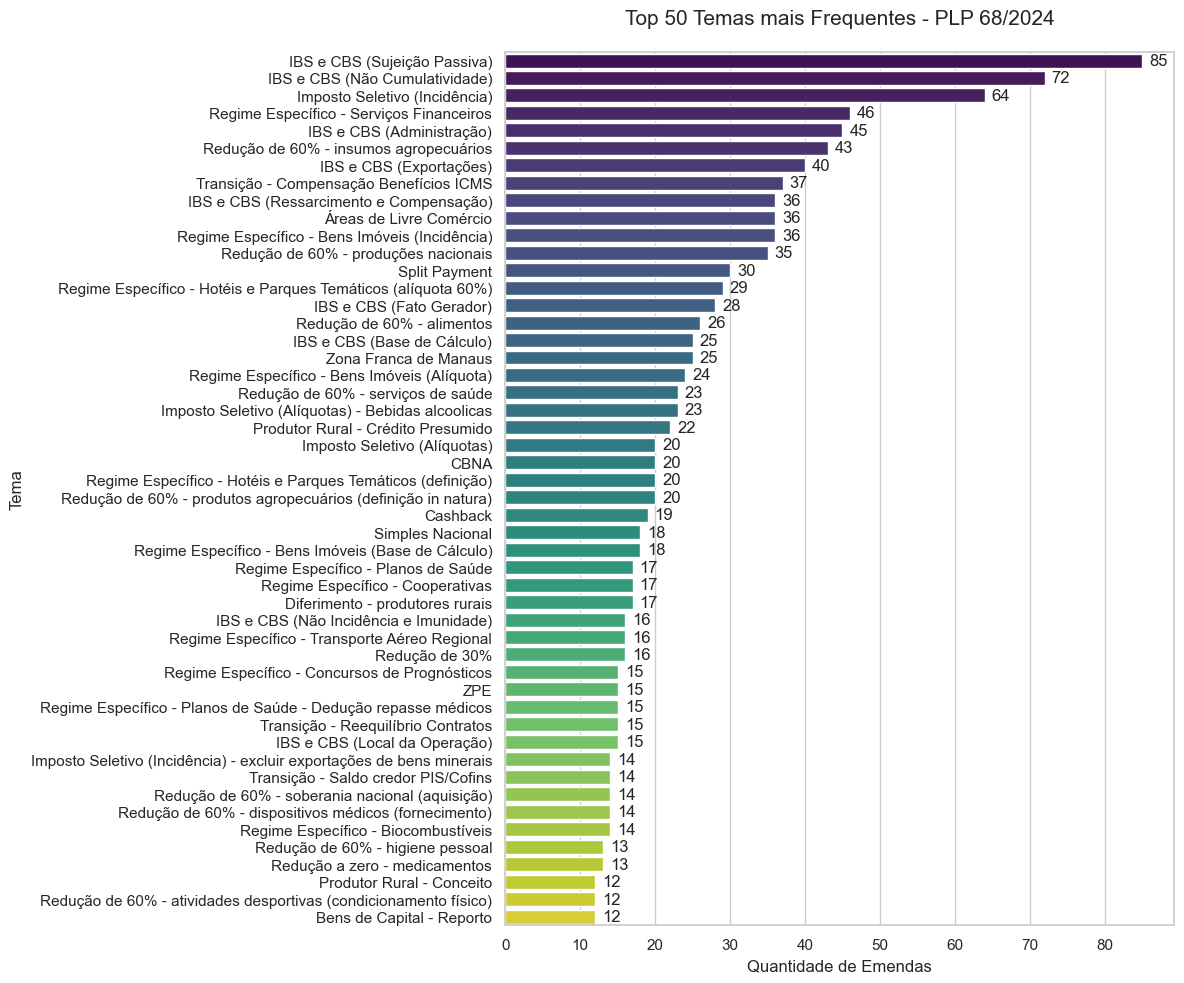

In [162]:
plot_tema_dist(df_plp_68_com_temas)

In [163]:
df_plp_68_com_temas["tema"].value_counts()

tema
IBS e CBS (Sujeição Passiva)                       85
IBS e CBS (Não Cumulatividade)                     72
Imposto Seletivo (Incidência)                      64
Regime Específico - Serviços Financeiros           46
IBS e CBS (Administração)                          45
                                                   ..
Regime Específico - Bares e Restaurantes            1
Imposto Seletivo (Período de apuração)              1
Redução a zero - dispositivos de acessibilidade     1
Redução de 60% - dispositivos de acessibilidade     1
SAF                                                 1
Name: count, Length: 261, dtype: int64

In [164]:
df_plp_68_com_temas.value_counts("tema_macro")

tema_macro
IBS e CBS                                                         475
Regime Específico                                                 399
Redução de 60%                                                    307
Imposto Seletivo                                                  185
Transição                                                          93
CBNA                                                               63
Redução a zero                                                     63
Produtor Rural                                                     51
Bens de Capital                                                    46
Áreas de Livre Comércio                                            36
Regime Diferenciado                                                34
Split Payment                                                      30
Zona Franca de Manaus                                              27
Matéria estranha                                                   21
Cashback 

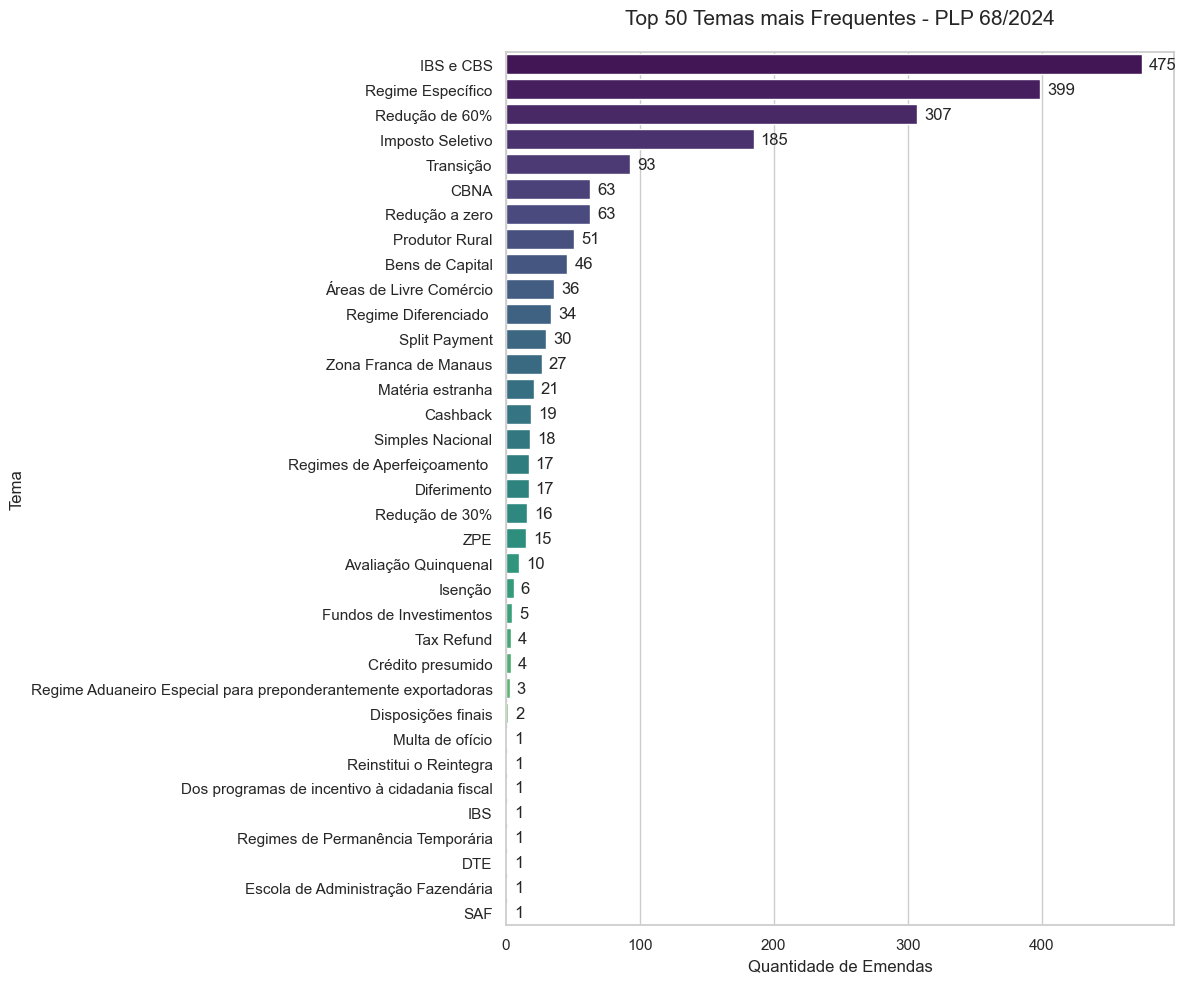

In [165]:
plot_tema_dist(df_plp_68_com_temas, "tema_macro")

In [166]:
df_plp_68_com_temas.value_counts("tema_nivel_2")

tema_nivel_2
Regime Específico - Bens Imóveis                                          118
Imposto Seletivo (Incidência)                                             116
IBS e CBS (Não Cumulatividade)                                             96
Transição                                                                  93
IBS e CBS (Sujeição Passiva)                                               85
                                                                         ... 
Regime Específico - Acordos Internacionais                                  1
Redução de 60% - transferência de conhecimento, tecnoloigia ou knowhow      1
Regimes de Permanência Temporária                                           1
Reinstitui o Reintegra                                                      1
SAF                                                                         1
Name: count, Length: 102, dtype: int64

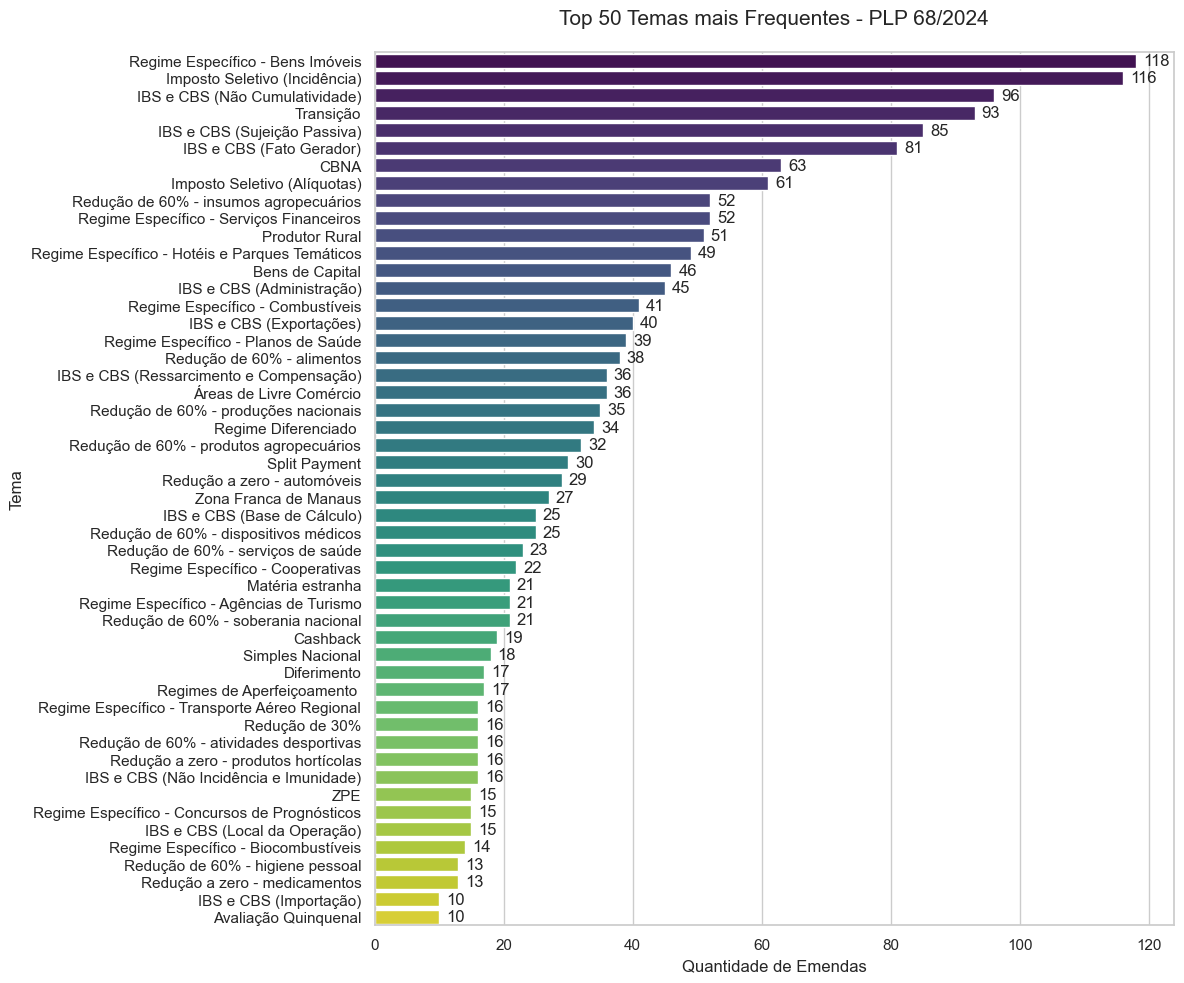

In [167]:
plot_tema_dist(df_plp_68_com_temas, "tema_nivel_2")

In [168]:
len(df_plp_68_com_temas)

1974

In [169]:
df_plp_68_com_temas.to_parquet("../data/temas/PLP_68_2024.parquet", index=False)

## Extração de temas do Quadro Comparativo da PEC 6/2019

### Extração de temas do PDF

In [98]:
import pdfplumber

pdf_path = "../data/quadros_emendas/PEC_6_2019/emendas-pec-6-sointese-2.pdf"

with pdfplumber.open(pdf_path) as pdf:
    page = pdf.pages[0]

    print(f"Largura: {page.width}")
    print(f"Altura: {page.height}")

    im = page.to_image(resolution=150)
    im.draw_rect((0, 0, page.width, page.height))
    im.show()
with pdfplumber.open(pdf_path) as pdf:
    for i, page in enumerate(pdf.pages):

        palavras = page.extract_words()

        for w in palavras:
            if w["text"] == "SÍNTESE":
                print(f"Página {i+1}")
                print(w)

Largura: 595.4
Altura: 841.8
Página 1
{'text': 'SÍNTESE', 'x0': 178.19200000000004, 'x1': 238.58380000000002, 'top': 111.68799999999999, 'doctop': 111.68799999999999, 'bottom': 129.688, 'upright': True, 'height': 18.0, 'width': 60.39179999999999, 'direction': 'ltr'}
Página 2
{'text': 'SÍNTESE', 'x0': 180.40000000000003, 'x1': 220.46320000000003, 'top': 215.58000000000004, 'doctop': 1057.38, 'bottom': 227.58000000000004, 'upright': True, 'height': 12.0, 'width': 40.063199999999995, 'direction': 'ltr'}


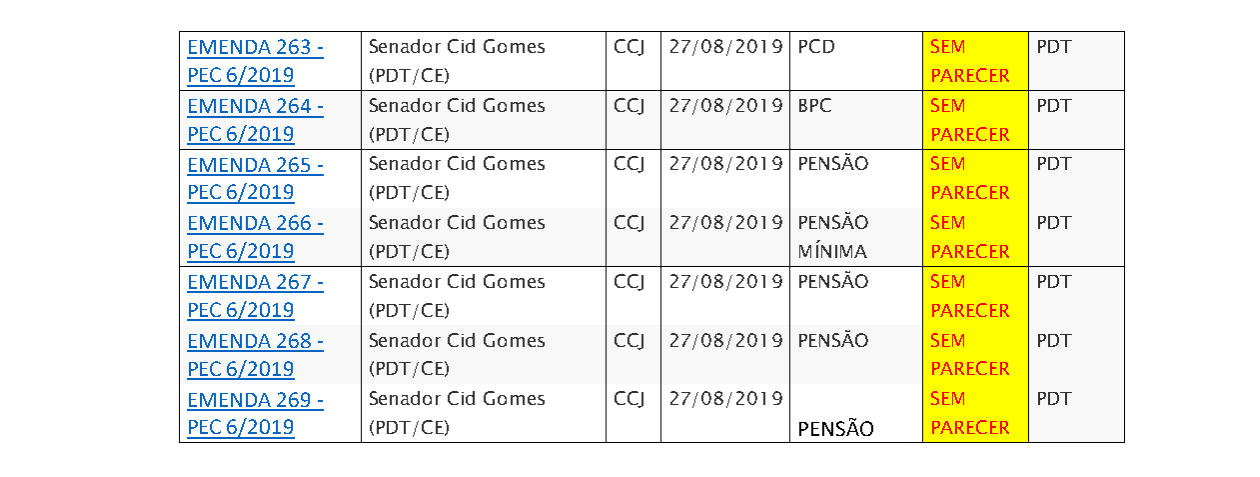

In [99]:
with pdfplumber.open(pdf_path) as pdf:
    page = pdf.pages[12]

    y_inicio = 60  # um pouco abaixo do título

    tabela_area = page.crop(
        (0, y_inicio, page.width, 280)
    )

    im = tabela_area.to_image(resolution=150)
    plt.figure(figsize=(16, 20))
    plt.imshow(im.original)
    plt.axis("off")
    plt.show()

595.4


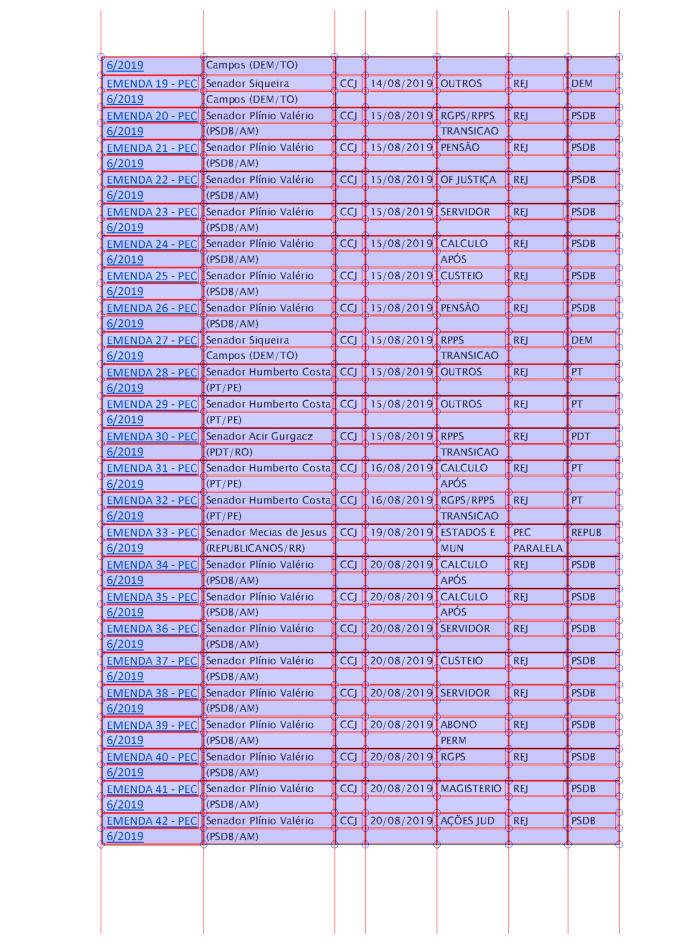

In [100]:
import pdfplumber
import matplotlib.pyplot as plt
table_settings = {
    "vertical_strategy": "explicit",
    "horizontal_strategy": "lines",

    "explicit_vertical_lines": [
        80,   # identificação
        170,  # autor
        285,  # org
        312,  # data
        375,  # tema
        438,  # delib
        490,   # partido
        535,
        
    ],

    "snap_y_tolerance": 8,
    "join_y_tolerance": 10,

    "intersection_tolerance": 12
}


with pdfplumber.open(pdf_path) as pdf:
    page = pdf.pages[2]

    y_inicio = 30
    y_fim = page.height

    palavras = page.extract_words()

    for w in palavras:
        if w["text"] == "QUANTIDADE":
            y_fim = w["top"] - 10
            break
    print(page.width)
    tabela_area = page.crop((0, y_inicio, page.width, y_fim))

    img = tabela_area.to_image(resolution=150)

    img.debug_tablefinder(table_settings)

    plt.figure(figsize=(12, 12))
    plt.imshow(img.annotated)
    plt.axis("off")
    plt.show()

In [101]:
import pdfplumber
import pandas as pd

pdf_path = "../data/quadros_emendas/PEC_6_2019/emendas-pec-6-sointese-2.pdf"

table_settings = {
    "vertical_strategy": "explicit",
    "horizontal_strategy": "lines",

    "explicit_vertical_lines": [
        80,   # identificação
        170,  # autor
        285,  # org
        312,  # data
        375,  # tema
        438,  # delib
        490,   # partido
        535
    ],

    "intersection_tolerance": 8,
    "snap_tolerance": 3,
    "join_tolerance": 3
}

all_rows = []


with pdfplumber.open(pdf_path) as pdf:

    for ix, page in enumerate(pdf.pages[1:-2]):

        palavras = page.extract_words()
        if ix == 0:
            y_inicio = 235
        else:
            y_inicio = 60
        if ix < 11:
            y_fim = page.height
        else:
            y_fim = 200

        for w in palavras:
            if w["text"] == "QUANTIDADE":
                y_fim = w["top"] - 10
                break

        tabela_area = page.crop(
            (0, y_inicio, page.width, y_fim)
        )

        table = tabela_area.extract_table(table_settings)

        if table:
            all_rows.extend(table)

# limpa
rows_limpos = [
    row for row in all_rows
    if any(cell.strip() for cell in row if cell)
]

# remove cabeçalho
rows_limpos = rows_limpos[1:]

# -------------------------
# agrupa dinamicamente
# -------------------------
grupos = []
grupo_atual = []

for row in rows_limpos:

    primeira_col = row[0].strip()

    if primeira_col.startswith("EMENDA") and grupo_atual:
        grupos.append(grupo_atual)
        grupo_atual = [row]
    else:
        grupo_atual.append(row)

if grupo_atual:
    grupos.append(grupo_atual)

# -------------------------
# consolida cada grupo
# -------------------------
registros = []

for grupo in grupos:

    cols = list(zip(*grupo))

    merged = [
        " ".join(str(c).strip() for c in col if str(c).strip())
        for col in cols
    ]
    print(merged)

    registro = {
        "identificacao": f"{merged[0]}",
        "autor": f"{merged[1]}",
        "org": merged[2],
        "data": merged[3],
        "tema": merged[4],
        "delib": merged[5],
        "partido": merged[6]
    }

    registro = {
        k: " ".join(v.split())
        for k, v in registro.items()
    }
    registro["emenda"] =  int(registro["identificacao"].split()[1])


    registros.append(registro)

df_pec_9 = pd.DataFrame(registros)

print(df_pec_9.head(20))
print(f"Total: {len(df_pec_9)}")

['EMENDA 1 - PEC 6/2019', 'Senador Otto Alencar (PSD/BA)', 'CCJ', '14/08/2019', 'CUSTEIO', 'REJ', 'PSD']
['EMENDA 2 - PEC 6/2019', 'Senador Otto Alencar (PSD/BA)', 'CCJ', '14/08/2019', 'PENSÃO MÍNIMA', 'PEC PARALELA', 'PSD']
['EMENDA 3 - PEC 6/2019', 'Senador Otto Alencar (PSD/BA)', 'CCJ', '14/08/2019', 'RGPS TRANSICAO', 'REJ', 'PSD']
['EMENDA 4 - PEC 6/2019', 'Senador Jader Barbalho (MDB/PA)', 'CCJ', '14/08/2019', 'ESTADOS E MUN', 'PEC PARALELA', 'MDB']
['EMENDA 5 - PEC 6/2019', 'Senador Carlos Viana (PSD/MG)', 'CCJ', '14/08/2019', 'MILITARES', 'REJ', 'PSD']
['EMENDA 6 - PEC 6/2019', 'Senador Siqueira Campos (DEM/TO)', 'CCJ', '14/08/2019', 'RPPS TRANSICAO', 'REJ', 'DEM']
['EMENDA 7 - PEC 6/2019', 'Senador Siqueira Campos (DEM/TO)', 'CCJ', '14/08/2019', 'PENSÃO MÍNIMA', 'PEC PARALELA', 'DEM']
['EMENDA 8 - PEC 6/2019', 'Senador Siqueira Campos (DEM/TO)', 'CCJ', '14/08/2019', 'CUSTEIO', 'REJ', 'DEM']
['EMENDA 9 - PEC 6/2019', 'Senador Weverton (PDT/MA)', 'CCJ', '14/08/2019', 'RPPS TRANSI

In [113]:
df_pec_9.tema.value_counts()

tema
CUSTEIO                28
RPPS TRANSICAO         25
PENSÃO                 20
CALCULO APÓS           19
SERVIDOR               18
OUTROS                 15
BPC                    14
RGPS/RPPS TRANSICAO    13
PENSÃO MÍNIMA          13
AP ESP                 11
ABONO PERM              9
RGPS TRANSICAO          9
APOS INVALIDEZ          9
ESTADOS E MUN           8
RGPS                    8
ABONO SAL               8
PREV COMPL              7
ACUM BENEF              6
POLICIAIS               6
PCD                     4
MAGISTERIO              4
ANISTIADOS              4
AÇÕES JUD               3
MILITARES               2
OF JUSTIÇA              2
RURAIS                  1
RGPS (REPETE 146)       1
CSLL BANCOS             1
TRIBUTACAO LUCROS       1
Name: count, dtype: int64

### Remoção de Emenda repetida (146)

In [114]:
df_pec_9 = df_pec_9[df_pec_9.emenda != 146].reset_index(drop=True)
df_pec_9

,identificacao,autor,org,data,tema,delib,partido,emenda
0,EMENDA 1 - PEC 6/2019,Senador Otto Alencar (PSD/BA),CCJ,14/08/2019,CUSTEIO,REJ,PSD,1
1,EMENDA 2 - PEC 6/2019,Senador Otto Alencar (PSD/BA),CCJ,14/08/2019,PENSÃO MÍNIMA,PEC PARALELA,PSD,2
2,EMENDA 3 - PEC 6/2019,Senador Otto Alencar (PSD/BA),CCJ,14/08/2019,RGPS TRANSICAO,REJ,PSD,3
3,EMENDA 4 - PEC 6/2019,Senador Jader Barbalho (MDB/PA),CCJ,14/08/2019,ESTADOS E MUN,PEC PARALELA,MDB,4
4,EMENDA 5 - PEC 6/2019,Senador Carlos Viana (PSD/MG),CCJ,14/08/2019,MILITARES,REJ,PSD,5
...,...,...,...,...,...,...,...,...
263,EMENDA 265 - PEC 6/2019,Senador Cid Gomes (PDT/CE),CCJ,27/08/2019,PENSÃO,SEM PARECER,PDT,265
264,EMENDA 266 - PEC 6/2019,Senador Cid Gomes (PDT/CE),CCJ,27/08/2019,PENSÃO MÍNIMA,SEM PARECER,PDT,266
265,EMENDA 267 - PEC 6/2019,Senador Cid Gomes (PDT/CE),CCJ,27/08/2019,PENSÃO,SEM PARECER,PDT,267
266,EMENDA 268 - PEC 6/2019,Senador Cid Gomes (PDT/CE),CCJ,27/08/2019,PENSÃO,SEM PARECER,PDT,268


In [121]:
df_pec_9["num_emenda"] = df_pec_9.identificacao.str.split().str[1].apply(lambda x:int(x))

In [124]:
df_pec_9.head()

,identificacao,autor,org,data,tema,delib,partido,num_emenda
0,EMENDA 1 - PEC 6/2019,Senador Otto Alencar (PSD/BA),CCJ,14/08/2019,CUSTEIO,REJ,PSD,1
1,EMENDA 2 - PEC 6/2019,Senador Otto Alencar (PSD/BA),CCJ,14/08/2019,PENSÃO MÍNIMA,PEC PARALELA,PSD,2
2,EMENDA 3 - PEC 6/2019,Senador Otto Alencar (PSD/BA),CCJ,14/08/2019,RGPS TRANSICAO,REJ,PSD,3
3,EMENDA 4 - PEC 6/2019,Senador Jader Barbalho (MDB/PA),CCJ,14/08/2019,ESTADOS E MUN,PEC PARALELA,MDB,4
4,EMENDA 5 - PEC 6/2019,Senador Carlos Viana (PSD/MG),CCJ,14/08/2019,MILITARES,REJ,PSD,5


In [125]:
df_pec_9.to_parquet("../data/temas/PEC_6_2019.parquet", index=False)

## Extração de temas do Quadro Comparativo da MPV 612/2013

### Extração de temas do docx

In [79]:
from docx import Document

doc = Document("../data/quadros_emendas/MPV_612_2013/Quadro_Emendas_MPV612_João_Robson.docx")
table = doc.tables[0]

# extrai linhas
dados = [
    [cell.text.strip().replace("\n", "").replace("\r", "") for cell in row.cells]
    for row in table.rows
]

# primeira linha vira header
df_mpv_612 = pd.DataFrame(dados[1:], columns=[d.lower() for d in dados[0]])

df_mpv_612.tail()

,nº,autor,tema,dispositivo alterado,descrição
215,216,Dep. Carmen Zanotto,Pronon e Pronas/PCD,Art. 23,Amplia o limite de dedução no IR dos programas...
216,217,Dep. Alfredo Kaefer,Benefício para quitação de débitos para com a RFB,acresce artigo,Visa conceder às empresas beneficiadas pela MP...
217,218,Dep. Alfredo Kaefer,Desoneração da folha de pagamentos,Art. 25,Inclui no regime de desoneração da folha de pa...
218,219,Dep. Alfredo Kaefer,Desoneração da folha de pagamentos,Art. 25,Torna facultativa a adesão ao regime de desone...
219,220,Dep. Alfredo Kaefer,Desoneração da folha de pagamentos,Art. 25,Torna facultativa a adesão ao regime de desone...


In [174]:
df_mpv_612.rename(columns={'nº': 'num_emenda'}, inplace=True)
df_mpv_612["num_emenda"] = df_mpv_612["num_emenda"].astype(int)

In [176]:
df_mpv_612.tema.value_counts()

tema
Desoneração da folha de pagamentos                                                                                                                                                                    60
Regime de exploração de Clia                                                                                                                                                                          47
Alfandegamento de locais e recintos aduaneiros                                                                                                                                                        14
Estranho à MPV – concede alíquota zero de PIS/Pasep e Cofins                                                                                                                                           7
Elevação do teto para opção pelo Lucro Presumido                                                                                                                                               

In [177]:
df_mpv_612.to_parquet("../data/temas/MPV_612_2013.parquet", index=False)